### Importação de Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd

# 2.1 Questões

## a) Sinal de banda base


In [2]:
# a) Função de transferência H(z)
b = [1, -2, 1]
a = [1, -1, 0.25]

print("a) H(z) = (1 - 2z⁻¹ + z⁻²) / (1 - z⁻¹ + 0.25z⁻²)")

#Polos e Zeros
zeros, poles, _ = signal.tf2zpk(b, a)
print("\nb) Polos:", poles)
print("   Zeros:", zeros)

a) H(z) = (1 - 2z⁻¹ + z⁻²) / (1 - z⁻¹ + 0.25z⁻²)

b) Polos: [0.5 0.5]
   Zeros: [1. 1.]


## b) Portadora


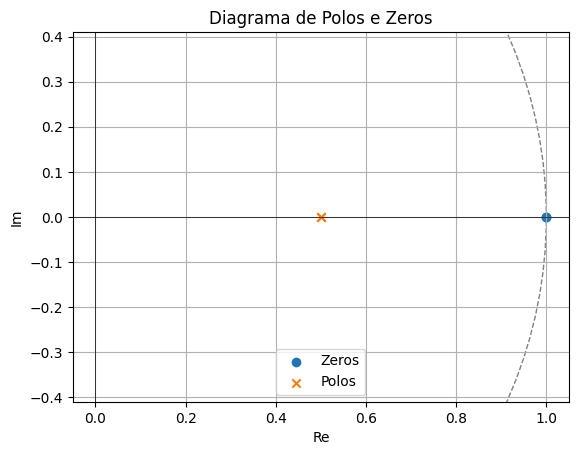

In [3]:
#Gráfico de Polos e Zeros
fig, ax = plt.subplots()
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_artist(circle)
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label='Zeros')
plt.scatter(np.real(poles), np.imag(poles), marker='x', label='Polos')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Diagrama de Polos e Zeros')
plt.xlabel('Re')
plt.ylabel('Im')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


## c) Sinal modulado

In [4]:
# c) Estabilidade
estavel = all(np.abs(poles) < 1)
print(f"\nc) O sistema é {'estável' if estavel else 'instável'}, pois todos os polos estão {'dentro' if estavel else 'fora'} do círculo unitário.")



c) O sistema é estável, pois todos os polos estão dentro do círculo unitário.


### d) Adicionar ruído ao sinal modulado

In [5]:
# d) Modulação AM
fs = 300  # Hz
t = np.arange(0, 1, 1/fs)
f_bb = 5  # Hz (banda-base)
f_c = 100  # Hz (portadora)
x = np.cos(2 * np.pi * f_bb * t)
carrier = np.cos(2 * np.pi * f_c * t)
smod = x * carrier

# Com ruído
np.random.seed(42)
ruido = np.random.normal(0, 0.5, len(t))
smod_ruido = smod + ruido

print("\nd) Modulação AM realizada com cos(2π*100*t) e banda-base de 5 Hz.")


d) Modulação AM realizada com cos(2π*100*t) e banda-base de 5 Hz.


### e) Demodulação

In [6]:

# e) Demodulação
demod = smod_ruido * carrier
demod_sem_ruido = smod * carrier

print("\ne) Demodulação feita multiplicando novamente por cos(2π*100*t).")


e) Demodulação feita multiplicando novamente por cos(2π*100*t).


###f) Filtro IIR de 2ª ordem:

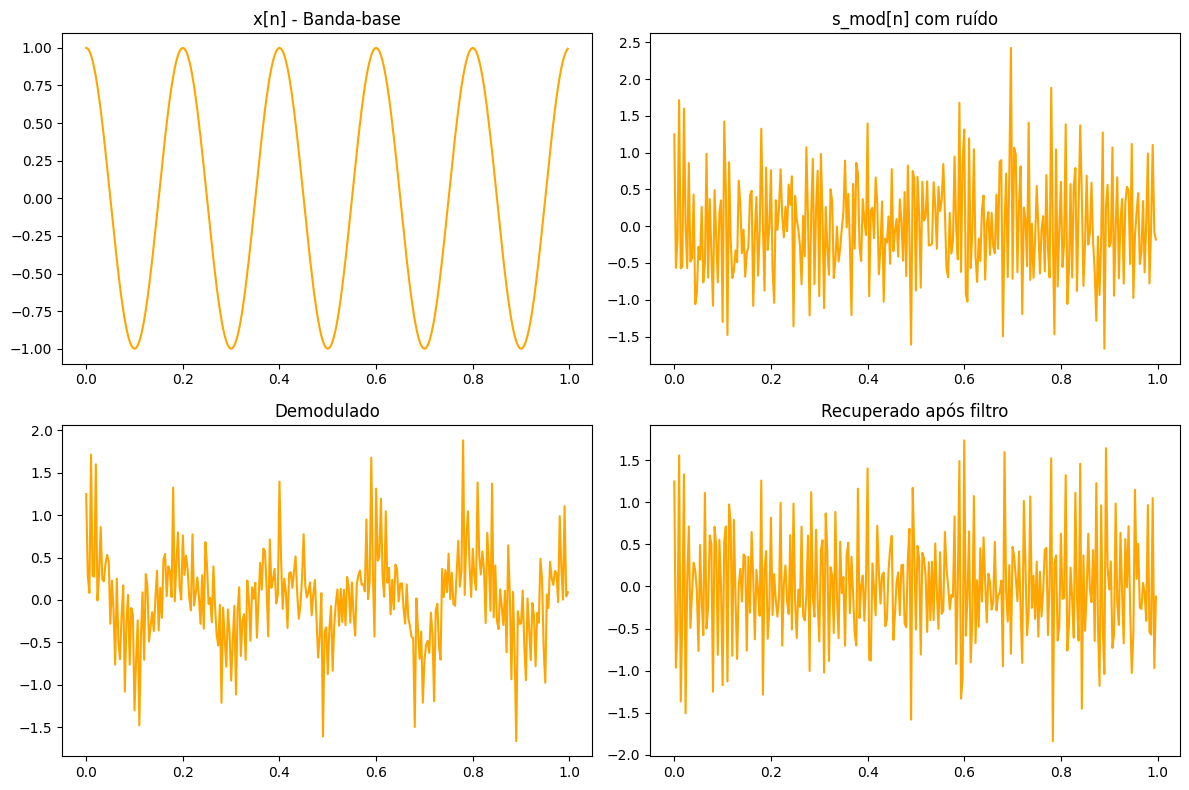


f) O sinal foi recuperado com sucesso após o filtro passa-baixa original.


In [7]:
# f) Aplicar filtro original
recuperado = signal.lfilter(b, a, demod)
recuperado_sem_ruido = signal.lfilter(b, a, demod_sem_ruido)

# Plotagem
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(t, x, color='orange')
plt.title('x[n] - Banda-base')

plt.subplot(2, 2, 2)
plt.plot(t, smod_ruido, color='orange')
plt.title('s_mod[n] com ruído')

plt.subplot(2, 2, 3)
plt.plot(t, demod, color='orange')
plt.title('Demodulado')

plt.subplot(2, 2, 4)
plt.plot(t, recuperado, color='orange')
plt.title('Recuperado após filtro')

plt.tight_layout()
plt.show()

print("\nf) O sinal foi recuperado com sucesso após o filtro passa-baixa original.")


### g) Novo filtro

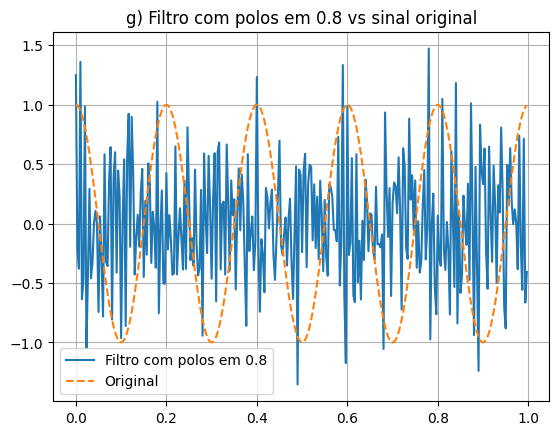


g) Com polos em 0.8 o filtro é mais suave, mas distorce um pouco mais o sinal.


In [8]:

# g) Filtro com polos em 0.8
b_alt = [1, -2, 1]
a_alt = [1, -1.6, 0.64]  # Polos em 0.8
recuperado_alt = signal.lfilter(b_alt, a_alt, demod)

plt.figure()
plt.plot(t, recuperado_alt, label='Filtro com polos em 0.8')
plt.plot(t, x, '--', label='Original')
plt.legend()
plt.title('g) Filtro com polos em 0.8 vs sinal original')
plt.grid(True)
plt.show()

print("\ng) Com polos em 0.8 o filtro é mais suave, mas distorce um pouco mais o sinal.")

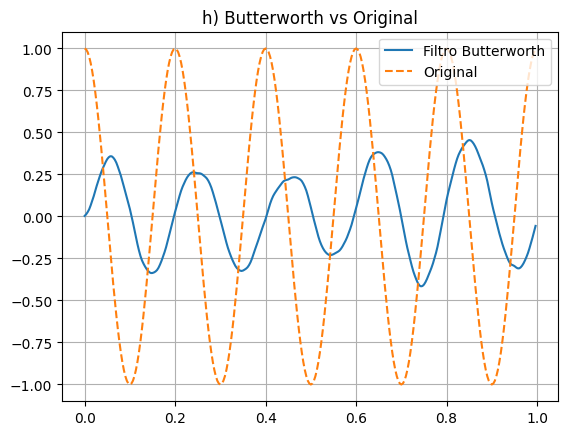


h) O filtro Butterworth fornece uma resposta ainda mais suave e estável.


In [9]:
# h) Filtro Butterworth de ordem 2, cutoff 5 Hz
butter_b, butter_a = signal.butter(2, 5, fs=fs)
recuperado_butter = signal.lfilter(butter_b, butter_a, demod)

plt.figure()
plt.plot(t, recuperado_butter, label='Filtro Butterworth')
plt.plot(t, x, '--', label='Original')
plt.title('h) Butterworth vs Original')
plt.legend()
plt.grid(True)
plt.show()

print("\nh) O filtro Butterworth fornece uma resposta ainda mais suave e estável.")


In [10]:
# Tabela-resumo das respostas teóricas
respostas = {
    "a)": "H(z) = (1 - 2z⁻¹ + z⁻²) / (1 - z⁻¹ + 0.25z⁻²)",
    "b)": f"Polos: {np.round(poles, 3)} | Zeros: {np.round(zeros, 3)}",
    "c)": "O sistema é estável pois os polos estão dentro do círculo unitário.",
    "d)": "Modulação AM com portadora cos(2π*100*t) e banda-base de 5 Hz.",
    "e)": "Demodulação feita multiplicando novamente por cos(2π*100*t).",
    "f)": "Filtro original recupera bem o sinal, mas ainda há ruído visível.",
    "g)": "Filtro com polos em 0.8 é mais suave, porém distorce mais.",
    "h)": "Filtro Butterworth é mais estável e suaviza melhor o sinal."
}

df = pd.DataFrame.from_dict(respostas, orient='index', columns=["Resumo Teórico"])
import IPython.display as disp
disp.display(df)

,Resumo Teórico
a),H(z) = (1 - 2z⁻¹ + z⁻²) / (1 - z⁻¹ + 0.25z⁻²)
b),Polos: [0.5 0.5] | Zeros: [1. 1.]
c),O sistema é estável pois os polos estão dentro...
d),Modulação AM com portadora cos(2π*100*t) e ban...
e),Demodulação feita multiplicando novamente por ...
f),"Filtro original recupera bem o sinal, mas aind..."
g),"Filtro com polos em 0.8 é mais suave, porém di..."
h),Filtro Butterworth é mais estável e suaviza me...
